# ResNet 코드 필사
### 6장 - 파이토치 사용법 II

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 코드 6-65 필요한 라이브러리 호출

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple  # ① 네임드튜플
import os
import random
import time

import cv2
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 device: {device}')

사용 device: cuda


## 코드 6-66 이미지 데이터 전처리

In [3]:
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),  # 훈련 이미지 데이터에 대한 전처리
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])   # 검증과 테스트 이미지 데이터에 대한 전처리
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

## 코드 6-67 변수에 대한 값 정의

In [4]:
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

## 코드 6-68 훈련과 테스트 데이터셋 불러오기

In [5]:
cat_directory = r'/content/drive/MyDrive/dogs-vs-cats (Unzipped Files)/Cat/'
dog_directory = r'/content/drive/MyDrive/dogs-vs-cats (Unzipped Files)/Dog'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

## 코드 6-69 데이터셋을 훈련, 검증, 테스트 용도로 분리

In [6]:
random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


## 코드 6-70 이미지에 대한 레이블 구분

In [7]:
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

## 코드 6-71 이미지 데이터셋 정의

In [8]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


## 코드 6-72 데이터셋의 데이터를 메모리로 불러오기

In [9]:
train_iterator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_iterator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_iterator, 'val': valid_iterator}

batch_iterator = iter(train_iterator)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 1, 0, 0])


## 코드 6-73 기본 블록 정의

In [10]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)  # 3×3 합성곱층
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)  # 3×3 합성곱층
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if downsample:  # ① 다운샘플 적용
            conv = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                             stride=stride, bias=False)
            bn = nn.BatchNorm2d(out_channels)
            downsample = nn.Sequential(conv, bn)
        else:
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += i  # ② 아이덴티티 매핑 적용
        x = self.relu(x)
        return x

## 코드 6-74 병목 블록 정의

In [11]:
class Bottleneck(nn.Module):
    expansion = 4  # ResNet에서 병목 블록을 정의하기 위한 하이퍼파라미터

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                               stride=1, bias=False)  # 1×1 합성곱층
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)  # 3×3 합성곱층
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, self.expansion * out_channels,
                               kernel_size=1, stride=1, bias=False)  # 1×1 합성곱층
        self.bn3 = nn.BatchNorm2d(self.expansion * out_channels)
        self.relu = nn.ReLU(inplace=True)

        if downsample:
            conv = nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1,
                             stride=stride, bias=False)
            bn = nn.BatchNorm2d(self.expansion * out_channels)
            downsample = nn.Sequential(conv, bn)
        else:
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += i
        x = self.relu(x)
        return x

## 코드 6-75 ResNet 모델 네트워크

In [12]:
class ResNet(nn.Module):
    def __init__(self, config, output_dim, zero_init_residual=False):
        super().__init__()

        block, n_blocks, channels = config
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4

        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2,
                               padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.get_resnet_layer(block, n_blocks[0], channels[0])
        self.layer2 = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
        self.layer3 = self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
        self.layer4 = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(self.in_channels, output_dim)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def get_resnet_layer(self, block, n_blocks, channels, stride=1):
        layers = []
        if self.in_channels != block.expansion * channels:
            downsample = True
        else:
            downsample = False

        layers.append(block(self.in_channels, channels, stride, downsample))
        for i in range(1, n_blocks):
            layers.append(block(block.expansion * channels, channels))

        self.in_channels = block.expansion * channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.fc(h)
        return x, h

## 코드 6-76 ResNetConfig 정의

In [13]:
ResNetConfig = namedtuple('ResNetConfig', ['block', 'n_blocks', 'channels'])

## 코드 6-77 기본 블록을 사용하여 ResNetConfig 정의

In [14]:
resnet18_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[2, 2, 2, 2],
                               channels=[64, 128, 256, 512])

resnet34_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[3, 4, 6, 3],
                               channels=[64, 128, 256, 512])

## 코드 6-78 병목 블록을 사용하여 ResNetConfig 정의

In [15]:
resnet50_config = ResNetConfig(block=Bottleneck,
                               n_blocks=[3, 4, 6, 3],
                               channels=[64, 128, 256, 512])

resnet101_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3, 4, 23, 3],
                                channels=[64, 128, 256, 512])

resnet152_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3, 8, 36, 3],
                                channels=[64, 128, 256, 512])

## 코드 6-79 사전 훈련된 ResNet 모델 사용

In [16]:
pretrained_model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


## 코드 6-80 사전 훈련된 ResNet 네트워크 확인

In [17]:
print(pretrained_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 코드 6-81 ResNet50 Config를 사용한 ResNet 모델 사용
사전 훈련된 ResNet50을 불러와 마지막 fc층만 2클래스(개/고양이)로 교체합니다.

In [18]:
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # 마지막 fc층만 2클래스로 교체
print(model.fc)

Linear(in_features=2048, out_features=2, bias=True)


## 코드 6-82 옵티마이저와 손실 함수 정의

In [19]:
optimizer = optim.Adam([
    {'params': model.fc.parameters(), 'lr': 1e-3},          # fc층은 높은 lr
    {'params': [p for n, p in model.named_parameters()
                if 'fc' not in n], 'lr': 1e-5}               # 나머지는 낮은 lr
])
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model = model.to(device)
criterion = criterion.to(device)

## 코드 6-83 모델 학습 정확도 측정 함수 정의

In [20]:
def calculate_topk_accuracy(y_pred, y, k=1):  # 이진분류이므로 k=1 고정
    with torch.no_grad():
        batch_size = y.shape[0]
        _, top_pred = y_pred.topk(k, 1)
        top_pred = top_pred.t()
        correct = top_pred.eq(y.view(1, -1).expand_as(top_pred))
        correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
        acc_1 = correct_1 / batch_size
        acc_k = correct_k / batch_size
    return acc_1, acc_k

## 코드 6-84 모델 학습 함수 정의

In [21]:
def train(model, iterator, optimizer, criterion, scheduler, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.train()
    for (x, y) in tqdm(iterator, desc='Training'):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred = model(x)             # models.resnet50은 텐서 하나만 반환
        loss = criterion(y_pred, y)

        acc_1, acc_5 = calculate_topk_accuracy(y_pred, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc_1 += acc_1.item()
        epoch_acc_5 += acc_5.item()

    scheduler.step()
    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

## 코드 6-85 모델 평가 함수 정의

In [22]:
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.eval()
    with torch.no_grad():
        for (x, y) in tqdm(iterator, desc='Evaluating'):
            x = x.to(device)
            y = y.to(device)
            y_pred = model(x)             # models.resnet50은 텐서 하나만 반환
            loss = criterion(y_pred, y)

            acc_1, acc_5 = calculate_topk_accuracy(y_pred, y)
            epoch_loss += loss.item()
            epoch_acc_1 += acc_1.item()
            epoch_acc_5 += acc_5.item()

    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

## 코드 6-86 모델 학습 시간 측정 함수 정의

In [23]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

## 코드 6-87 모델 학습

In [24]:
best_valid_loss = float('inf')
EPOCHS = 10

for epoch in range(EPOCHS):
    start_time = time.monotonic()

    train_loss, train_acc_1, train_acc_5 = train(model, train_iterator, optimizer,
                                                  criterion, scheduler, device)
    valid_loss, valid_acc_1, valid_acc_5 = evaluate(model, valid_iterator, criterion,
                                                     device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/dogs-vs-cats (Unzipped Files)/ResNet-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc_1*100:6.2f}%')
    print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc: {valid_acc_1*100:6.2f}%')

Evaluating: 100%|██████████| 3/3 [00:01<00:00,  2.81it/s]


Epoch: 01 | Epoch Time: 0m 12s
	Train Loss: 0.372 | Train Acc:  86.06%
	Valid Loss: 0.124 | Valid Acc:  97.92%


Evaluating: 100%|██████████| 3/3 [00:01<00:00,  2.83it/s]


Epoch: 02 | Epoch Time: 0m 7s
	Train Loss: 0.113 | Train Acc:  97.36%
	Valid Loss: 0.056 | Valid Acc: 100.00%


Evaluating: 100%|██████████| 3/3 [00:00<00:00,  3.55it/s]


...

Epoch: 08 | Epoch Time: 0m 9s
	Train Loss: 0.012 | Train Acc:  99.76%
	Valid Loss: 0.020 | Valid Acc: 100.00%


Evaluating: 100%|██████████| 3/3 [00:00<00:00,  3.62it/s]


Epoch: 09 | Epoch Time: 0m 9s
	Train Loss: 0.013 | Train Acc: 100.00%
	Valid Loss: 0.020 | Valid Acc: 100.00%


Evaluating: 100%|██████████| 3/3 [00:00<00:00,  3.52it/s]


Epoch: 10 | Epoch Time: 0m 7s
	Train Loss: 0.012 | Train Acc:  99.76%
	Valid Loss: 0.020 | Valid Acc: 100.00%


## 코드 6-88 테스트 데이터셋을 이용한 모델 예측

In [25]:
id_list = []
pred_list = []

with torch.no_grad():
    for test_path in test_images_filepaths:
        img = Image.open(test_path)
        _id = test_path.split('/')[-1]          # 파일명 전체를 id로 저장 (예: cat.123.jpg)
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)                    # 텐서 하나만 반환
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.to_csv('/content/drive/MyDrive/dogs-vs-cats (Unzipped Files)/ResNet.csv', index=False)
res.head(10)

,id,label
0,cat.145.jpg,0.003264
1,dog.211.jpg,0.999597
2,cat.162.jpg,0.000910
3,cat.200.jpg,0.003251
4,cat.210.jpg,0.000263
5,cat.224.jpg,0.001119
6,dog.213.jpg,0.999030
7,cat.109.jpg,0.000735
8,cat.15.jpg,0.003543
9,dog.167.jpg,0.985883


## 코드 6-89 모델 예측에 대한 결과 출력

**수정 핵심**: 이미지마다 해당 파일명으로 예측값을 직접 조회합니다.
기존 코드의 `random.choice()`는 이미지와 무관한 랜덤 id를 뽑아서 결과가 뒤죽박죽이었습니다.

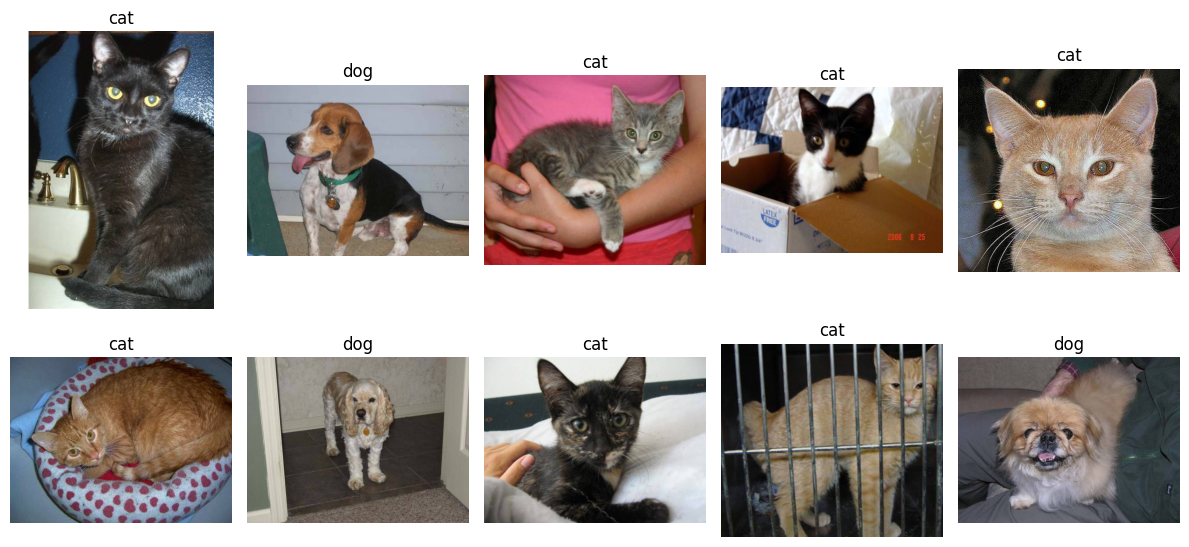

In [26]:
class_ = {0: 'cat', 1: 'dog'}

def display_image_grid(images_filepaths, cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # ✅ 수정: 현재 이미지의 파일명으로 예측값을 직접 조회
        filename = image_filepath.split('/')[-1]
        label_val = res.loc[res['id'] == filename, 'label'].values[0]

        label = 1 if label_val > 0.5 else 0

        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

display_image_grid(test_images_filepaths)